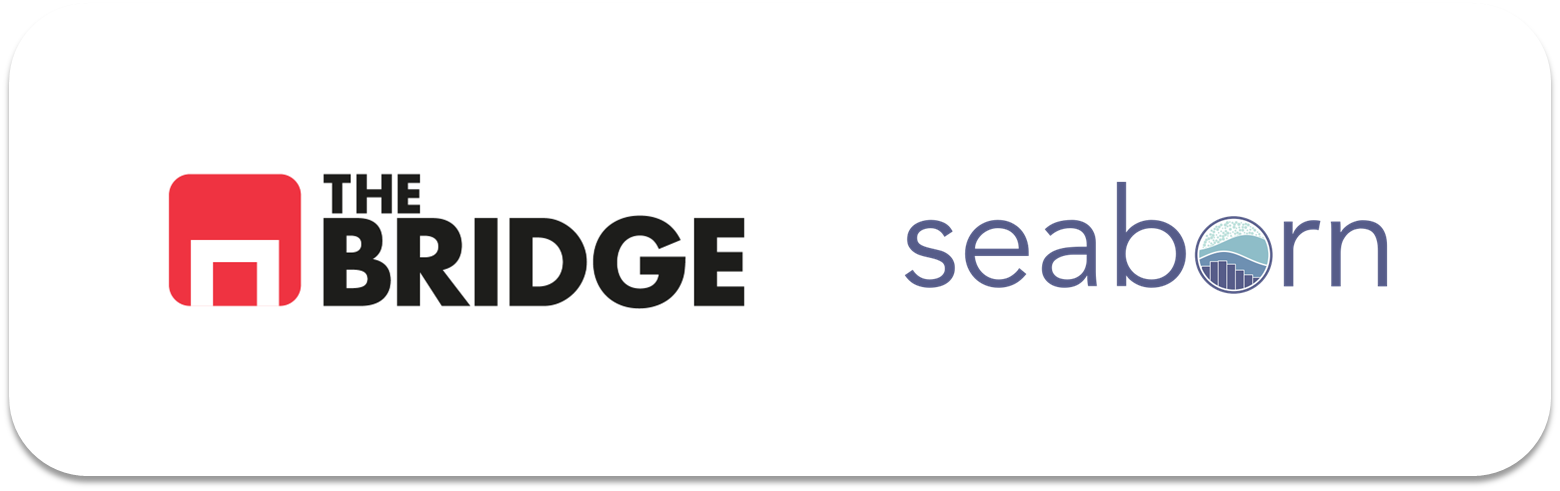

## PRACTICA OBLIGATORIA: **Visualización y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

pd.options.mode.copy_on_write = True

## #1 VISUALIZACION

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [2]:
df_california_cities = pd.read_csv("./data/california_cities.csv")
df_california_cities

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


In [3]:
df = df_california_cities.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [5]:
#Buscamos nulos
df.isna().sum().sort_values(ascending = False)

elevation_m           48
elevation_ft          12
area_total_km2         5
area_water_percent     5
area_land_km2          4
area_water_km2         4
area_total_sq_mi       2
area_water_sq_mi       1
Unnamed: 0             0
city                   0
latd                   0
longd                  0
area_land_sq_mi        0
population_total       0
dtype: int64

- Como nos explicaron en la sesion anterior aplicare las mismas funciones para poder reconstruir la columna de `elevation_m` con la información de `elevation_ft`

In [6]:
df["elevation_m_from_ft"] = df.elevation_ft * 0.3048 # Buscamos en internet que un pie son 0.3048 metros

In [7]:
df["elevation_m"] = df["elevation_m"].fillna(df["elevation_m_from_ft"])

In [8]:
df.isna().sum().sort_values(ascending=False)

elevation_ft           12
elevation_m_from_ft    12
elevation_m             8
area_total_km2          5
area_water_percent      5
area_water_km2          4
area_land_km2           4
area_total_sq_mi        2
area_water_sq_mi        1
population_total        0
latd                    0
Unnamed: 0              0
longd                   0
city                    0
area_land_sq_mi         0
dtype: int64

In [9]:
df = df.dropna() # eliminamos nulos

In [10]:
df.info()# verificamos

<class 'pandas.core.frame.DataFrame'>
Index: 464 entries, 0 to 481
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           464 non-null    int64  
 1   city                 464 non-null    object 
 2   latd                 464 non-null    float64
 3   longd                464 non-null    float64
 4   elevation_m          464 non-null    float64
 5   elevation_ft         464 non-null    float64
 6   population_total     464 non-null    int64  
 7   area_total_sq_mi     464 non-null    float64
 8   area_land_sq_mi      464 non-null    float64
 9   area_water_sq_mi     464 non-null    float64
 10  area_total_km2       464 non-null    float64
 11  area_land_km2        464 non-null    float64
 12  area_water_km2       464 non-null    float64
 13  area_water_percent   464 non-null    float64
 14  elevation_m_from_ft  464 non-null    float64
dtypes: float64(12), int64(2), object(1)
memory us

### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA OPCIONAL: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños.

In [11]:
df

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent,elevation_m_from_ft
0,0,Adelanto,34.576111,-117.432778,875.0000,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03,875.0808
1,1,AgouraHills,34.153333,-118.761667,281.0000,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37,281.0256
2,2,Alameda,37.756111,-122.274444,10.0584,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79,10.0584
3,3,Albany,37.886944,-122.297778,13.1064,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28,13.1064
4,4,Alhambra,34.081944,-118.135000,150.0000,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01,149.9616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,477,Yountville,38.403056,-122.362222,30.0000,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00,29.8704
478,478,Yreka,41.726667,-122.637500,787.0000,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72,786.9936
479,479,YubaCity,39.134722,-121.626111,18.0000,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53,17.9832
480,480,Yucaipa,34.030278,-117.048611,798.0000,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02,797.9664


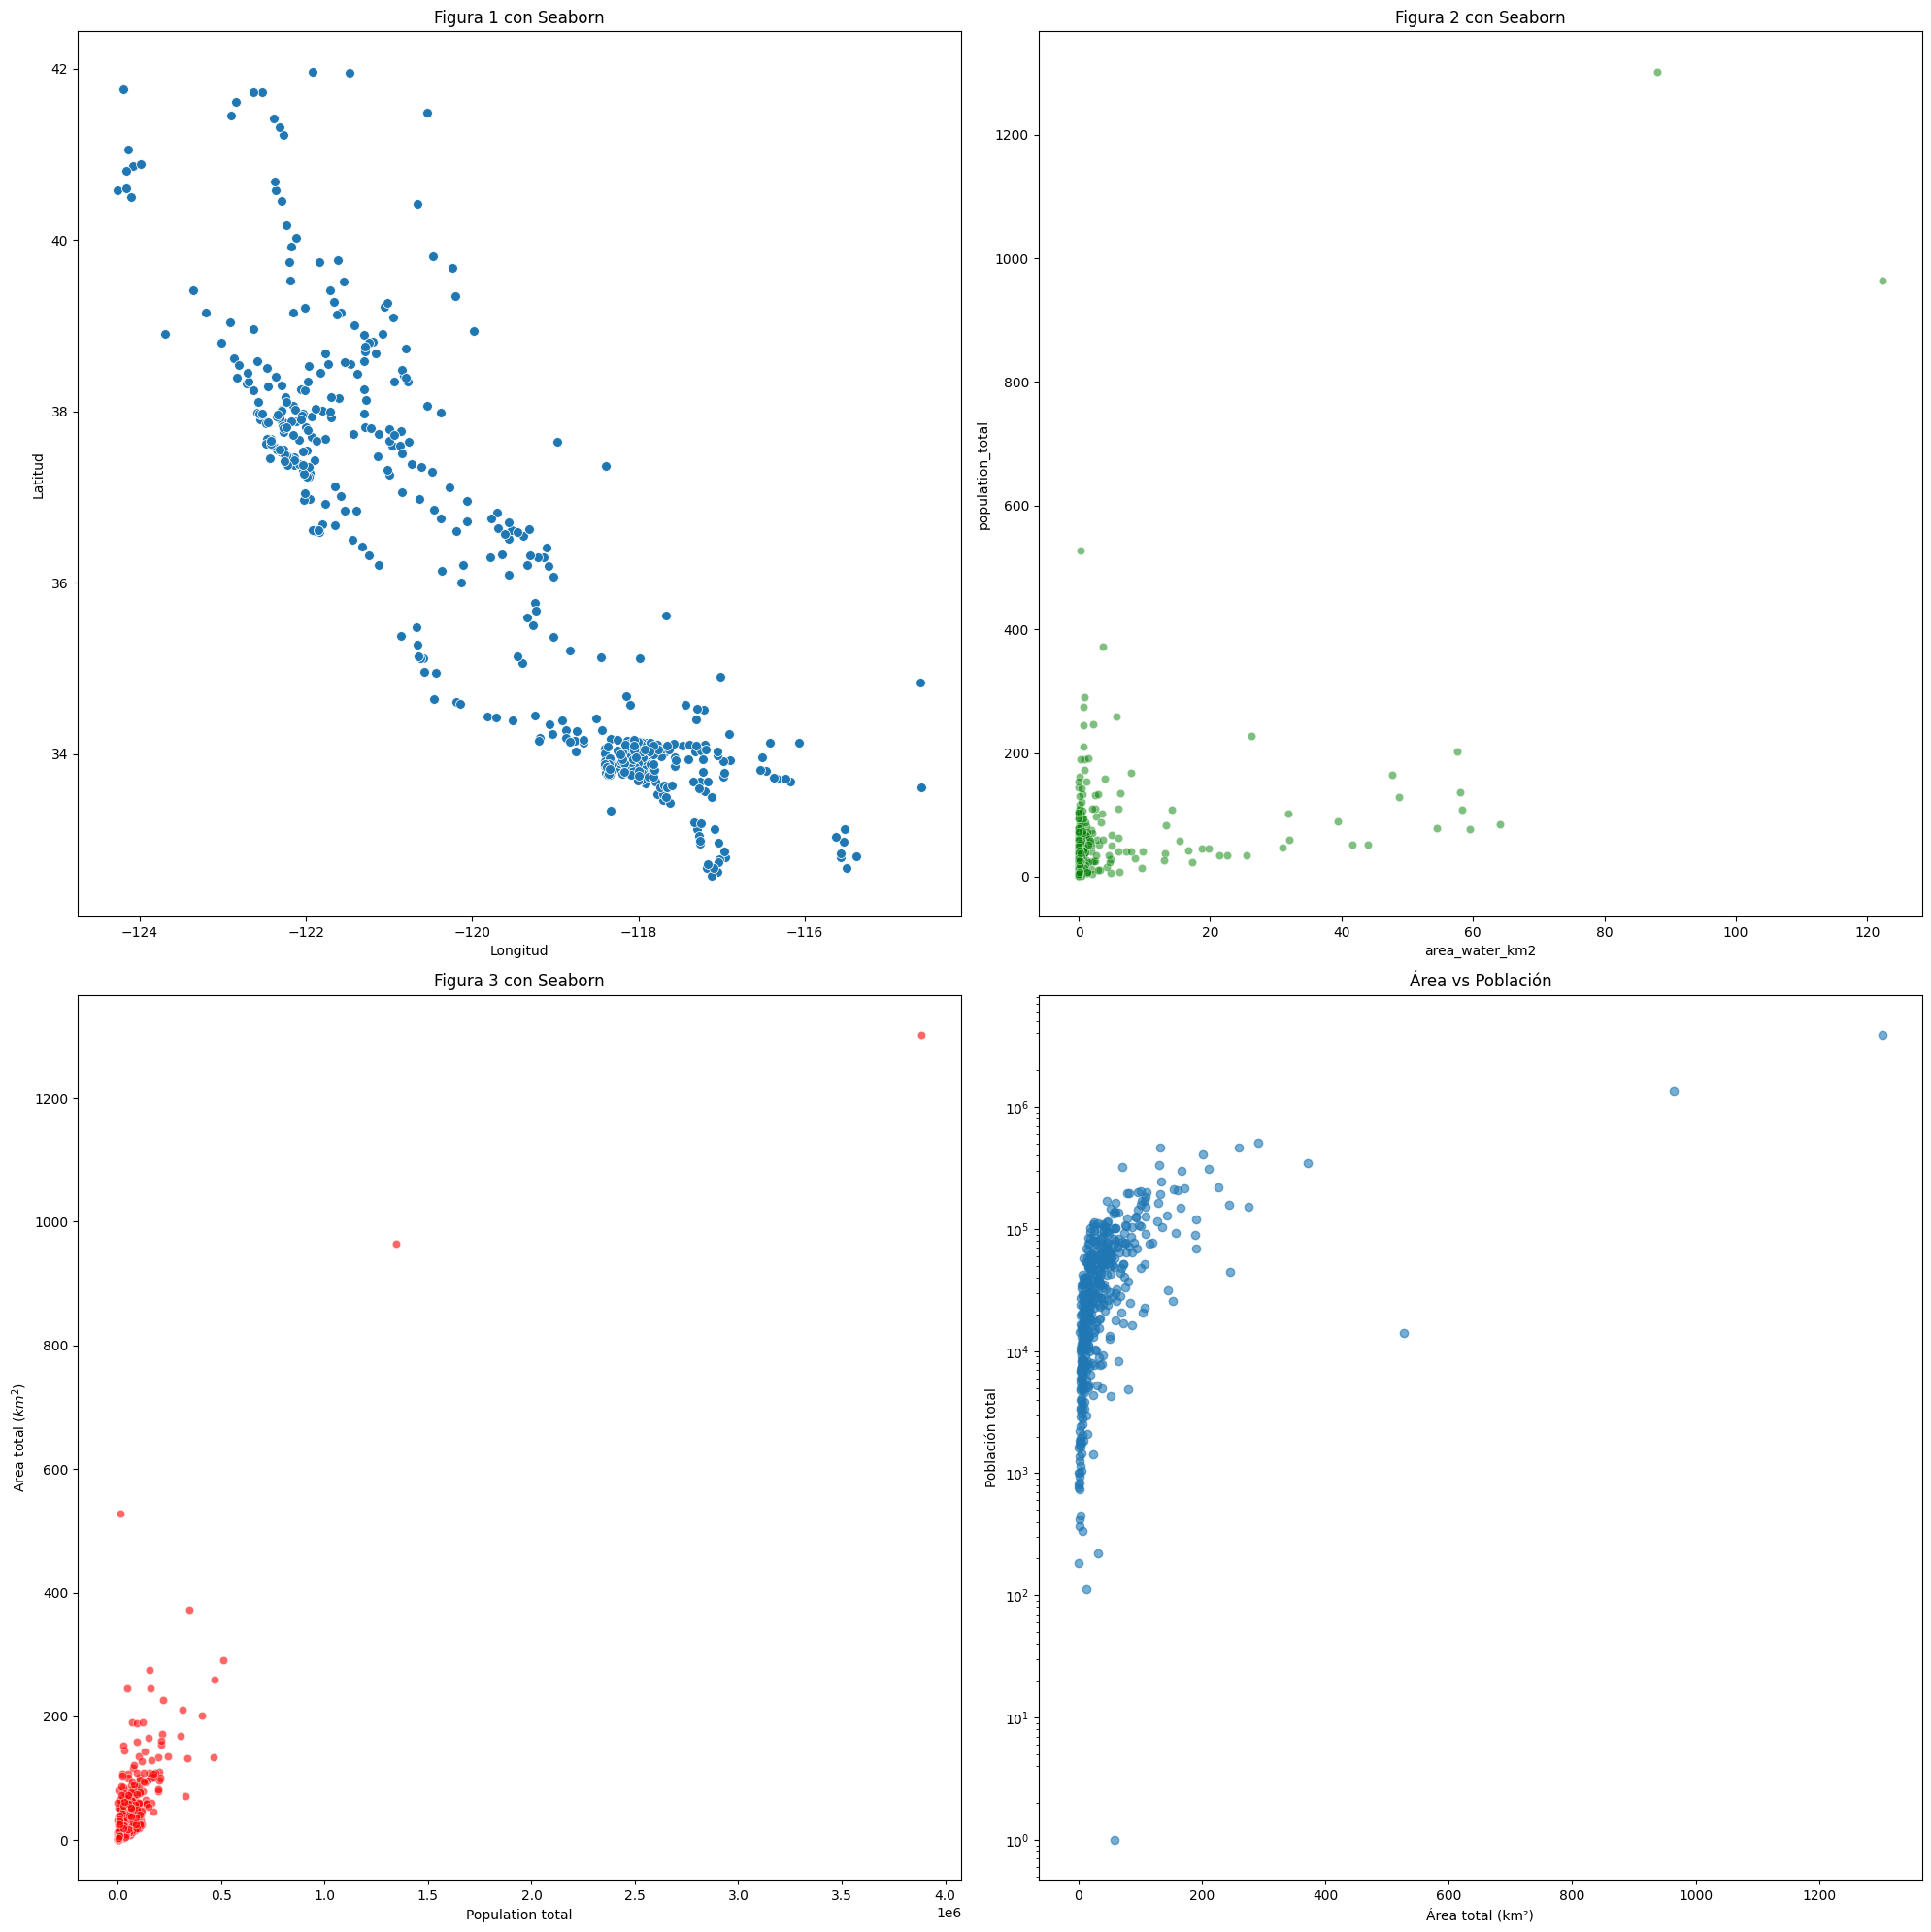

In [ ]:
# PRIMER SUBPLOT
plt.figure(figsize=(20,20))

plt.subplot(2,2,1)

sns.scatterplot(data= df, # Usamos Seaborn
                x="longd",
                y="latd",
                s= 50)

plt.ylabel("Latitud")
plt.xlabel("Longitud")
plt.title("Figura 1 con Seaborn")




# SEGUNDO SUBPLOT
plt.subplot(2,2,2)

sns.scatterplot(x= df["area_water_km2"], # Usamos Seaborn
                y= df["area_total_km2"],
                color= "green",
                alpha= 0.5,
                edgecolors="white")

plt.xlabel("area_water_km2") #
plt.ylabel("population_total") #
plt.title("Figura 2 con Seaborn")



# TERCER SUBPLOT
plt.subplot(2,2,3)

sns.scatterplot(x= df["population_total"], # Usamos Seaborn
                y= df["area_total_km2"],
                color= "red",
                alpha= 0.6,
                edgecolors="white")

plt.ylabel("Area total ($km^2$)") #
plt.xlabel("Population total") #
plt.title("Figura 3 con Seaborn")


 4. Un columna categórica (Opcional, valor por defecto None)
 - Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.


In [23]:
ciudades_mas_pobladas = 15 # prueba 10–20, en este caso filtrare para 15
top = (df.groupby("city", as_index=False)["population_total"].sum()
         .sort_values("population_total", ascending=False)
         .head(ciudades_mas_pobladas))

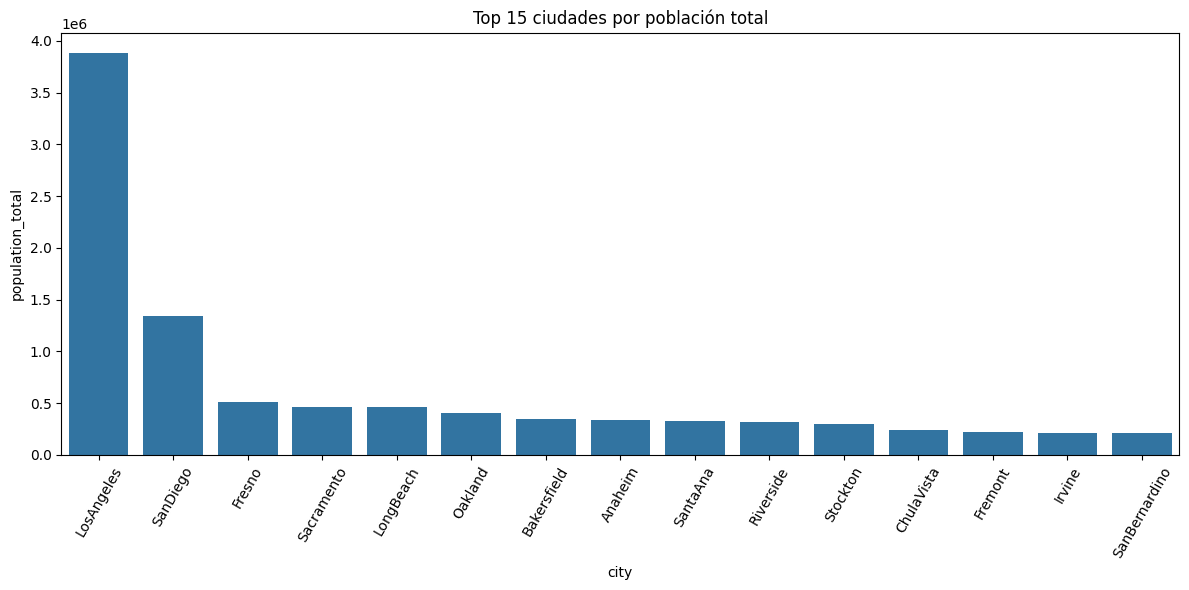

In [ ]:
# Barplot: población total por ciudad (Top 15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top, x="city", y="population_total")
plt.xticks(rotation=60)
plt.title("Top 15 ciudades por población total")
plt.tight_layout()
plt.show()


5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de
las columnas del dataframe cuyos valores deben controlar el tamaño con el alpha

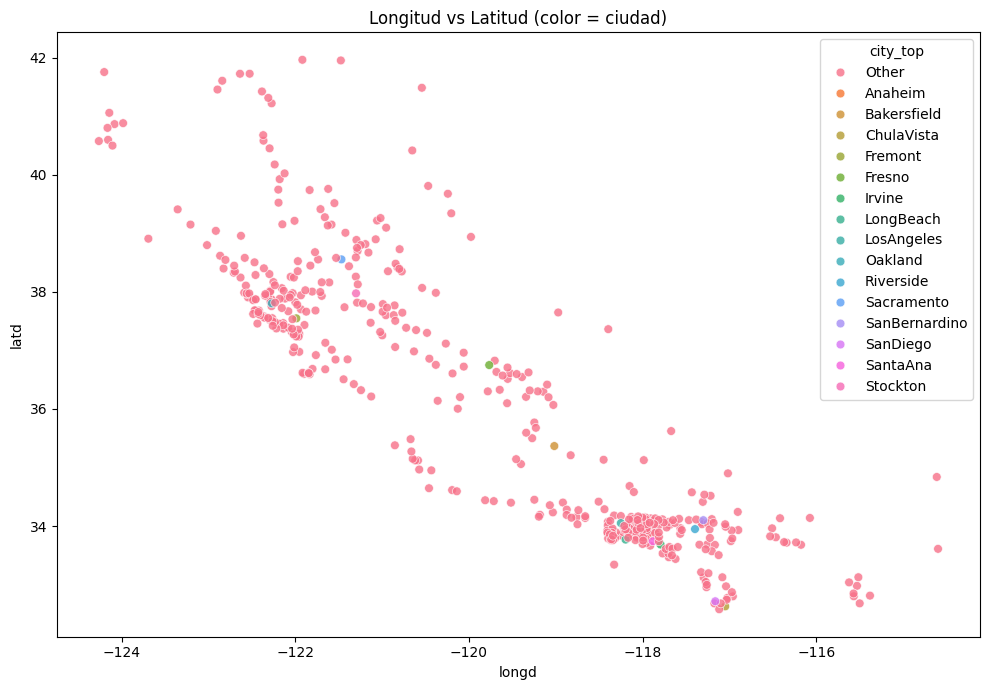

In [ ]:
def plot_city_map(df, city_col="city_top"):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df, x="longd", y="latd",
        hue=city_col,
        s=40, alpha=0.8
    )
    plt.title("Longitud vs Latitud (color = ciudad)")
    plt.tight_layout()
    plt.show()


plot_city_map(df)

6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

In [44]:
#Este punto lo utilice pidiendole ayuda a chat en base al punto 5 ya que no sabia bien como dividir

def scatter_city(
    df, x, y,
    cat_col=None,        # categórica (hue) opcional
    size=40,             # número (constante) o string (columna)
    scale=1.0,           # SOLO se usa si size es string
    alpha=0.7
):
    df = df.copy()

    # 1) hue opcional
    hue_kw = {"hue": cat_col} if cat_col is not None else {}

    # 2) tamaño: constante o por columna * scale
    if isinstance(size, str):
        # convierte a numérico por si acaso
        df[size] = pd.to_numeric(df[size], errors="coerce")

        s = df[size] * scale

        # evita tamaños 0/NaN y extremos (opcional pero recomendado)
        s = s.fillna(0)
        s = s.clip(lower=5, upper=s.quantile(0.95) if s.max() > 0 else 5)
    else:
        s = size

    # 3) plot (UNA sola figura)
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df, x=x, y=y,
        s=s, alpha=alpha,
        **hue_kw
    )
    plt.title(f"{y} vs {x}" + (f" (color={cat_col})" if cat_col else ""))
    plt.tight_layout()
    plt.show()

TypeError: cannot convert the series to <class 'float'>

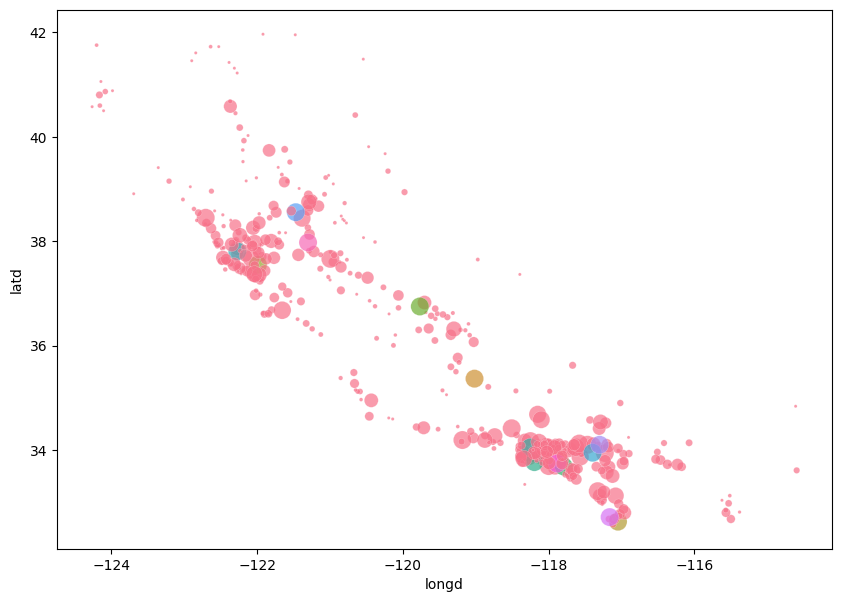

In [47]:
scatter_city(
    df,
    x="longd", y="latd",
    cat_col="city_top",          # o "city" si no creaste city_top
    size="population_total",
    scale=1/1000,                # ajusta: 1/2000 (más pequeño) o 1/500 (más grande)
    alpha=0.7
)

### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Una vez calculado el logaritmo, también puedes probar a categorizar la población, aquí tienes un ejemplo de como podría salir para que lo tengas de referencia:

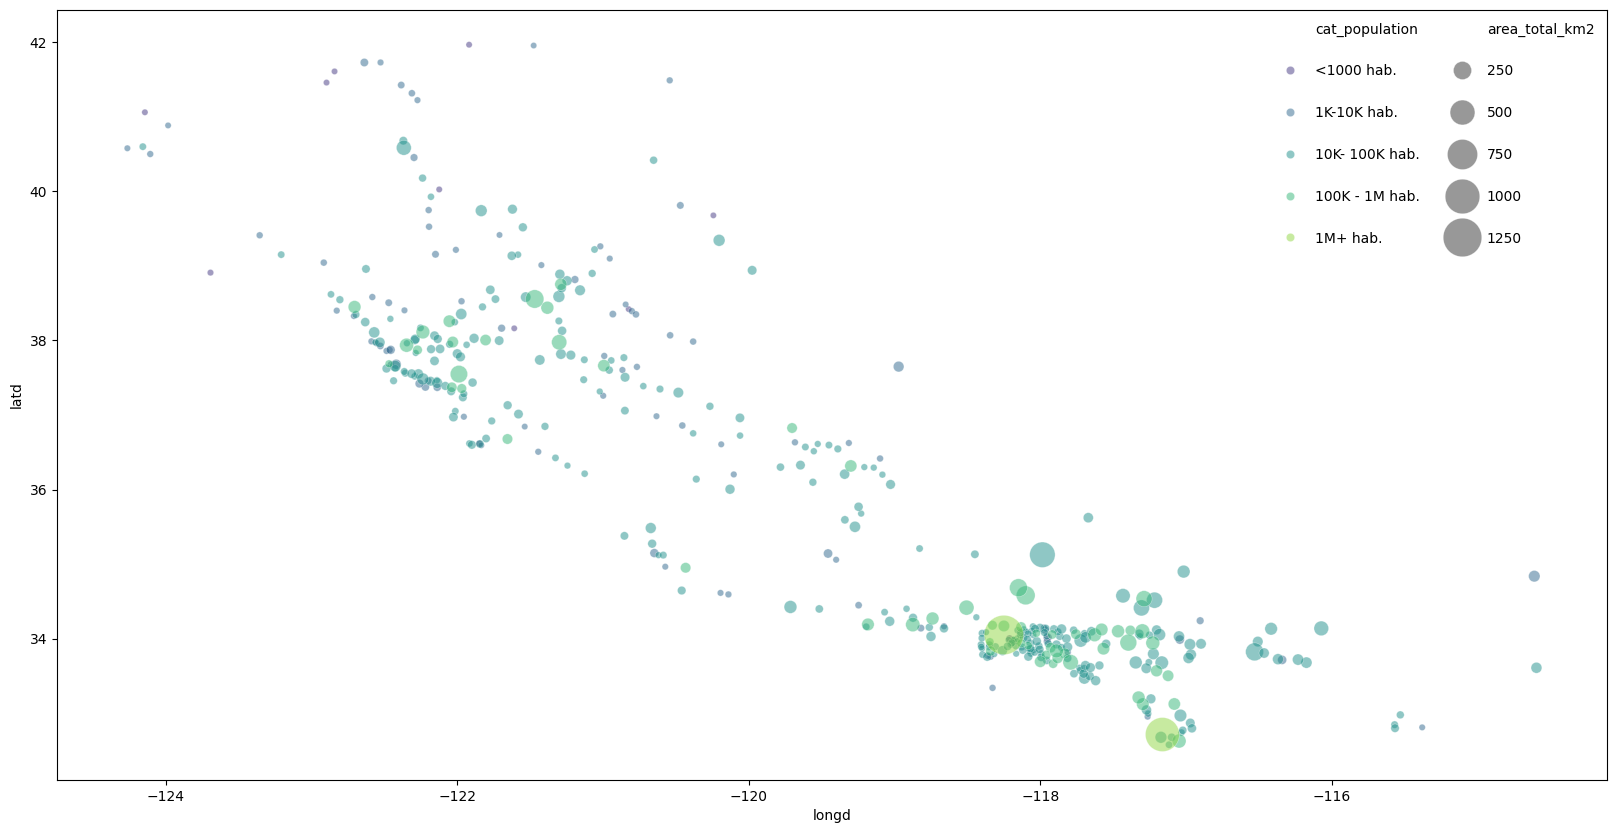

## #2: Presentación

En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

Y generar el notebook con las gráficas que vas a emplear en la presentación. Tienes que entregar ambas cosas.

In [49]:
df_titanic = pd.read_csv("./data/titanic.csv")

In [50]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


Total pasajeros: 891
Supervivencia: 38.4% | Mortalidad: 61.6%


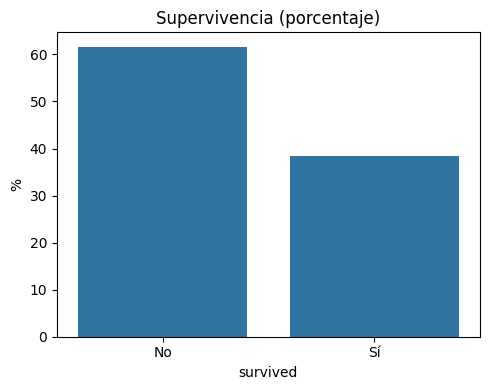

Supervivencia por sexo (%):
sex
female    74.2
male      18.9
Name: survived, dtype: float64


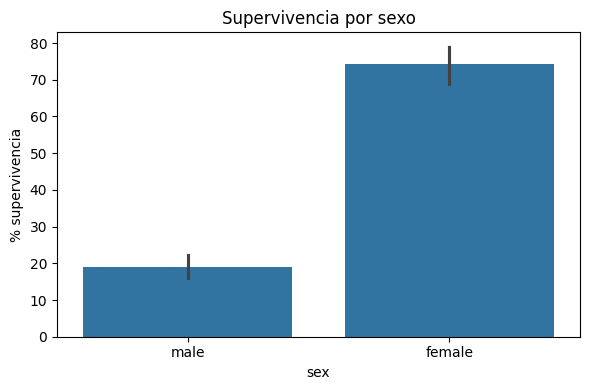

Supervivencia por clase (%):
pclass
1    63.0
2    47.3
3    24.2
Name: survived, dtype: float64


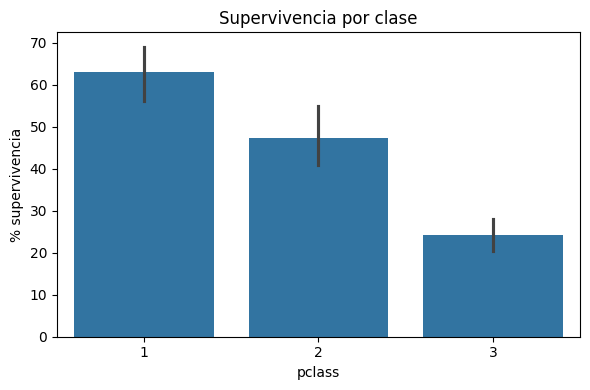

Supervivencia por grupo (%):
Group
women       77.5
children    59.0
male        17.4
Name: survived, dtype: float64


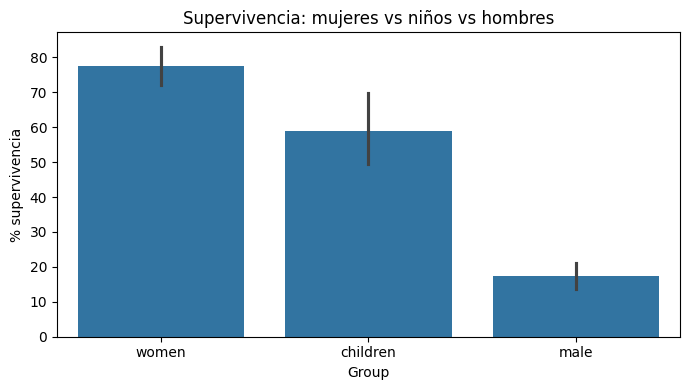

Supervivencia (%) por embark_town y pclass:
pclass           1     2     3
embark_town                   
Cherbourg     69.4  52.9  37.9
Queenstown    50.0  66.7  37.5
Southampton   58.3  46.3  19.0
unknown      100.0   NaN   NaN


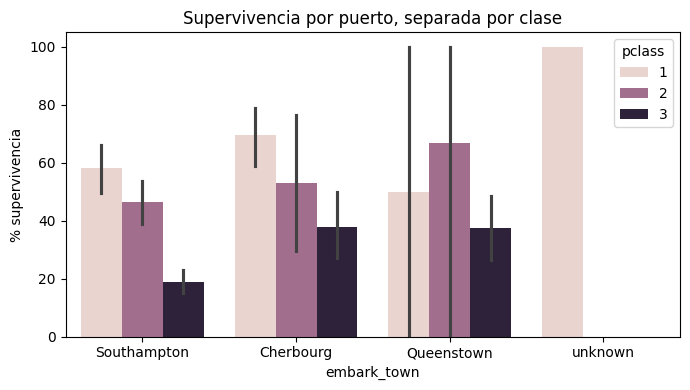

In [66]:
# Limpieza mínima
df_titanic  = df_titanic.dropna(subset=["survived", "sex", "pclass"])
df_titanic["embarked"] = df_titanic["embarked"].fillna("unknown")

#Slide 1 
total = len(df_titanic)
surv_rate = df_titanic["survived"].mean() * 100
mort_rate = 100 - surv_rate
print(f"Total pasajeros: {total}")
print(f"Supervivencia: {surv_rate:.1f}% | Mortalidad: {mort_rate:.1f}%")

# Slide 1: barra Survived (%)
plt.figure(figsize=(5,4))
sns.barplot(x=df_titanic["survived"].map({0:"No", 1:"Sí"}).value_counts(normalize=True).index,
            y=df_titanic["survived"].map({0:"No", 1:"Sí"}).value_counts(normalize=True).values*100)
plt.ylabel("%")
plt.title("Supervivencia (porcentaje)")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------------------------------------------------------

# Slide 2 
sex_rates = df_titanic.groupby("sex")["survived"].mean() * 100
print("Supervivencia por sexo (%):")
print(sex_rates.round(1))

# Slide 2: supervivencia por sexo
plt.figure(figsize=(6,4))
sns.barplot(data=df_titanic, x="sex", y="survived", estimator=lambda x: x.mean()*100)
plt.ylabel("% supervivencia")
plt.title("Supervivencia por sexo")
plt.tight_layout()
plt.show()
 
# --------------------------------------------------------------------------------------------------------------------------------------------

# Slide 3
class_rates = df_titanic.groupby("pclass")["survived"].mean() * 100
print("Supervivencia por clase (%):")
print(class_rates.round(1))

# Slide 3: supervivencia por clase
plt.figure(figsize=(6,4))
sns.barplot(data=df_titanic, x="pclass", y="survived", estimator=lambda x: x.mean()*100)
plt.ylabel("% supervivencia")
plt.title("Supervivencia por clase")
plt.tight_layout()
plt.show()


#---------------------------------------------------------------------------------------------------------------------------------------------


# Slide 4: Men / Women / Children

df2 = df_titanic.dropna(subset=["age"]).copy()
df2["Group"] = "male"
df2.loc[df2["sex"]=="female", "Group"] = "women"
df2.loc[df2["age"] < 16, "Group"] = "children"

group_rates = df2.groupby("Group")["survived"].mean() * 100
print("Supervivencia por grupo (%):")
print(group_rates.reindex(["women", "children", "male"]).round(1))

plt.figure(figsize=(7,4))
order = ["women", "children", "male"]
sns.barplot(data=df2, x="Group", y="survived", order=order, estimator=lambda x: x.mean()*100)
plt.ylabel("% supervivencia")
plt.title("Supervivencia: mujeres vs niños vs hombres")
plt.tight_layout()
plt.show()


#-----------------------------------------------------------------------------------------------------------------------------------------------

# Slide 5: Embarked parece influir, pero separado por clase
df5 = df_titanic.copy()
df5["embark_town"] = df5["embark_town"].fillna("unknown")

# % supervivencia por puerto y clase
rates = df5.groupby(["embark_town", "pclass"])["survived"].mean().mul(100).round(1)
print("Supervivencia (%) por embark_town y pclass:")
print(rates.unstack())   # tabla: filas=embarked, columnas=pclass

# Gráfica
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=df5, x="embark_town", y="survived", hue="pclass",
    estimator=lambda x: x.mean()*100
)
plt.ylabel("% supervivencia")
plt.title("Supervivencia por puerto, separada por clase")
plt.tight_layout()
plt.show()


In [64]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [65]:
df_titanic["embark_town"]

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: object